In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score

In [4]:
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df=pd.read_csv(url)

#display first five rows
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [5]:
#Seperate input and output
X=df[['displacement']]
y=df['mpg']
#checking missing values
print("Missing Values in ",X.isnull().sum())
print("Missing values in mpg:",y.isnull().sum())


Missing Values in  displacement    0
dtype: int64
Missing values in mpg: 0


In [6]:
#Remove rows containing missing values
data=df[['displacement', 'mpg']].dropna()

 #update input and output
X=data[['displacement']]
y=data['mpg']

#Display the selected area
print("Features:")
print(X.head())

print("\nTarget")
print(y.head())

Features:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
     random_state=42
)

print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))

Training Samples: 318
Testing Samples: 80


In [9]:
#create linear model regression
linear_model=LinearRegression()

#Train the model
linear_model.fit(X_train,y_train)

#predict on test data
y_pred_linear=linear_model.predict(X_test)

In [15]:
#calculate MSE
mse_linear=mean_squared_error(y_test,y_pred_linear)

#calculate r-squared
r2_linear=r2_score(y_test,y_pred_linear)


print("Linear Regression Results")
print("-------------------------")
print("MSE:",mse_linear)
print("R-SQUARED",r2_linear)

Linear Regression Results
-------------------------
MSE: 18.102543998358946
R-SQUARED 0.6633114869465595


In [22]:
#store results
results=[]

#store polynomial models for ploting
polynomial_models={}

#Add Linear Regression results
results.append({
    'Model': 'Linear Regression',
    'Degree': 1,
    'MSE':mse_linear,
    'R_Squared':r2_linear
})

#try polynomial degrees from 2 to 5
for degree in range(2,6):

    #create polynomial features
    poly=PolynomialFeatures(degree=degree)

    #Transform training and testing data
    X_train_poly=poly.fit_transform(X_train)
    X_test_poly=poly.transform(X_test)

    #Create linear regression model
    poly_model=LinearRegression()

    #Train Polynmial regression model
    poly_model.fit(X_train_poly,y_train)

    #Make predictions
    y_pred_poly=poly_model.predict(X_test_poly)

    #calculate mean square
    mse=mean_squared_error(y_test,y_pred_poly)

    #calculate r-squared
    r2 =r2_score(y_test,y_pred_poly)

    #store results
    results.append({
        'Model':'Polynomial Regression',
        'Degree': degree,
        'MSE':mse,
        'R_Squared':r2
    })
    
    #store model and polynomial transformer
    polynomial_models[degree]={
    'poly':poly,
    'model':poly_model
    }

In [23]:
#Convert resultd into dataframe
results_df=pd.DataFrame(results)

#display results
results_df

,Model,Degree,MSE,R_Squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


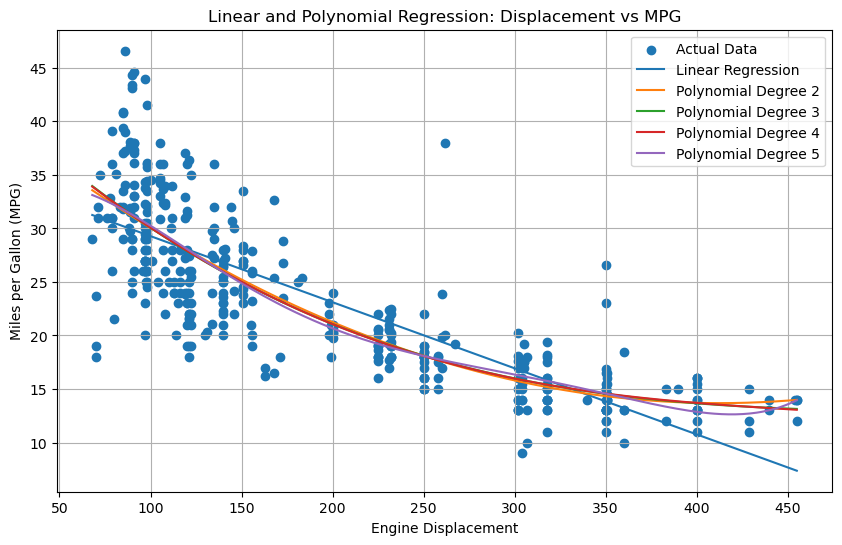

In [30]:
X_plot=pd.DataFrame({
    'displacement':np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300)
})
#create figure
plt.figure(figsize=(10,6))

#plot actual data
plt.scatter(
    X['displacement'],
    y,
    label='Actual Data'
)

y_plot_linear=linear_model.predict(X_plot)

plt.plot(
    X_plot['displacement'],
    y_plot_linear,
    label='Linear Regression'
)

for degree in range(2,6):
    poly=polynomial_models[degree]['poly']
    poly_model=polynomial_models[degree]['model']

    X_plot_poly=poly.transform(X_plot)

    y_plot_poly=poly_model.predict(X_plot_poly)

    plt.plot(
        X_plot['displacement'],
        y_plot_poly,
        label=f'Polynomial Degree {degree}'
    )


plt.xlabel('Engine Displacement')
plt.ylabel('Miles per Gallon (MPG)')

plt.title(
    'Linear and Polynomial Regression: Displacement vs MPG'
)
plt.legend()
plt.grid(True)
plt.show()

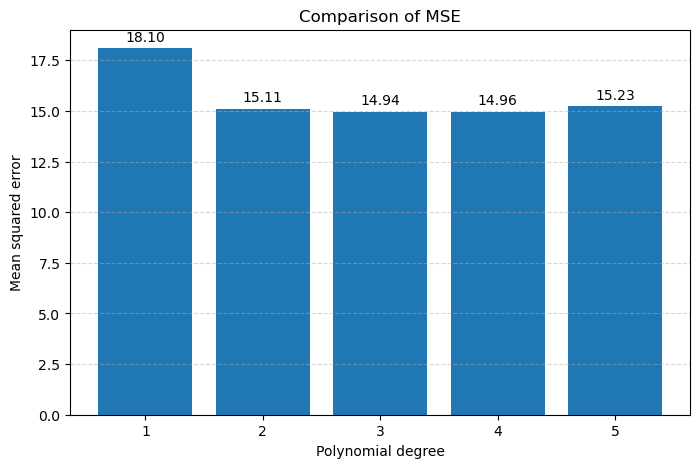

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Create bar plot
bars = plt.bar(results_df["Degree"].astype(str), results_df["MSE"])

# Add labels above bars
plt.bar_label(bars, fmt="%.2f", padding=3)

# Axis labels and title
plt.xlabel("Polynomial degree")
plt.ylabel("Mean squared error")
plt.title("Comparison of MSE")


plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

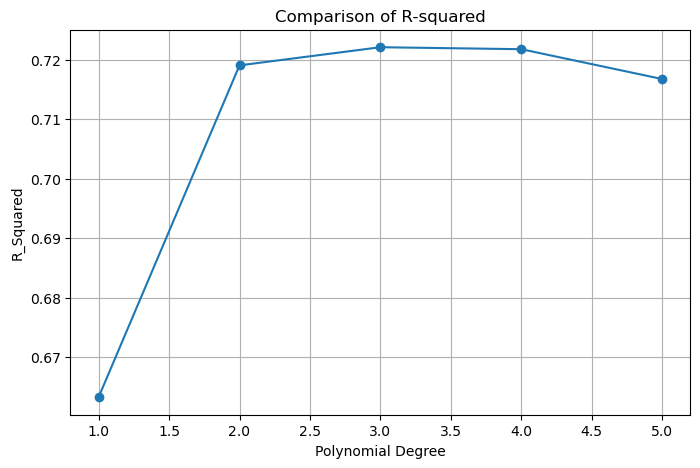

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df['Degree'],
    results_df['R_Squared'],
    marker='o',
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R_Squared")
plt.title("Comparison of R-squared")


plt.grid(True)

plt.show()